 # Notebook_05: Segmentacion promocional (K-Means)

En este Notebook se pretende responder a la siguiente pregunta

- ¿que perfiles de comportamiento promocional existen entre los hogares, y a quien le estamos dando el descuento?

Se aplicará un modelo no supervisado K-Means para responder a dicha pregunta de negocio. Para ello se utilizará el CLV utilizado en el Notebook 03.

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
drive.mount('/content/drive')

RUTA_DATOS = '/content/drive/MyDrive/UCM -master Data Science/TFM/data/dunnhumby/'
RUTA_PROCESADOS = '/content/drive/MyDrive/UCM -master Data Science/TFM/data/processed/'
RUTA_FIGURAS = '/content/drive/MyDrive/UCM -master Data Science/TFM/figuras/'

trans = pd.read_csv(RUTA_PROCESADOS + 'transactions_clean.csv')
products = pd.read_csv(RUTA_DATOS + 'product.csv')
redemptions = pd.read_csv(RUTA_DATOS + 'coupon_redempt.csv')
clv = pd.read_csv(RUTA_PROCESADOS + 'clv_por_hogar.csv')


Mounted at /content/drive


In [3]:
#Transacciones
len(trans)

2576815

In [4]:
#Hogares
trans['household_key'].nunique()

2500

In [5]:
# Añadir marca (National vs Private) a las transacciones
trans = trans.merge(products[['PRODUCT_ID', 'BRAND']], on='PRODUCT_ID', how='left')
trans.head(5)

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC,tiene_retail_disc,tiene_coupon_disc,tiene_match_disc,PRICE_PAID,PRICE_SHELF,DISCOUNT_PCT,BRAND
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0,True,False,False,1.39,1.99,0.301508,Private
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0,False,False,False,0.82,0.82,0.000000,National
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0,True,False,False,0.99,1.29,0.232558,Private
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0,False,False,False,1.21,1.21,0.000000,National
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0,True,False,False,1.50,1.89,0.206349,Private


# Construcción de variables que describen como compra cada hogar

Para segmentar los hogares por su comportamiento promocional, primero
construyo variables que describen cómo compra cada uno:
- cuánto gasta en total,
- cuántas veces viene,
- qué descuento medio capta,
-  qué porcentaje de sus compras son en promoción,
-  cuánto compra de marca
blanca, y su ticket medio.

La idea es agrupar hogares por su forma
de comprar, no por cuánto valen (eso ya lo hice en el notebook de CLV).

Marco como "con descuento" las transacciones con más de un 5% de
rebaja, y como marca blanca las de tipo Private.

In [6]:
# Marcar transacciones con descuento
trans['con_descuento'] = (trans['DISCOUNT_PCT'] > 0.05).astype(int)
trans['es_private'] = (trans['BRAND'] == 'Private').astype(int)




In [7]:
perfil = trans.groupby('household_key').agg(
    gasto_total=('SALES_VALUE', 'sum'),
    n_visitas=('BASKET_ID', 'nunique'),
    descuento_medio=('DISCOUNT_PCT', 'mean'),
    pct_compras_promo=('con_descuento', 'mean'),
    pct_marca_blanca=('es_private', 'mean'),
    ticket_medio=('SALES_VALUE', 'mean')
).reset_index()

In [8]:

# Gasto por visita
perfil['gasto_por_visita'] = perfil['gasto_total'] / perfil['n_visitas']

In [9]:
perfil.describe()

,household_key,gasto_total,n_visitas,descuento_medio,pct_compras_promo,pct_marca_blanca,ticket_medio,gasto_por_visita
count,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,3222.977520,110.215600,0.134968,0.482047,0.290283,3.167655,31.728286
std,721.83216,3349.026493,115.271006,0.038221,0.096986,0.107895,0.997907,19.116288
min,1.00000,8.170000,1.000000,0.013179,0.085714,0.000000,1.167296,2.387500
25%,625.75000,970.740000,38.000000,0.108937,0.419056,0.213745,2.600047,18.432270
50%,1250.50000,2157.750000,78.000000,0.129988,0.480164,0.282077,3.033409,27.488567
75%,1875.25000,4413.320000,142.000000,0.155436,0.543373,0.358273,3.530107,40.619277
max,2500.00000,38319.790000,1298.000000,0.364231,0.868613,0.873737,17.726162,165.829310


In [10]:
# Canjea cupones
hogares_canjean = redemptions['household_key'].unique()
perfil['canjea_cupones'] = perfil['household_key'].isin(hogares_canjean).astype(int)


# K-Means necesita variables en la misma escala.

K-Means necesita variables en la misma escala. El gasto_total va en miles y los porcentajes entre 0 y 1 por ese motivo hay que estandarizar.

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [12]:
# Variables que describen el comportamiento promocional
variables = ['descuento_medio', 'pct_compras_promo', 'pct_marca_blanca',
             'gasto_por_visita', 'n_visitas']

X = perfil[variables]


In [13]:


# Estandarizar: media 0, desviacion 1
scaler = StandardScaler()
X_esc = scaler.fit_transform(X)

In [14]:

# Metodo del codo: probar de 2 a 8 clusters
inercias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_esc)
    inercias.append(km.inertia_)

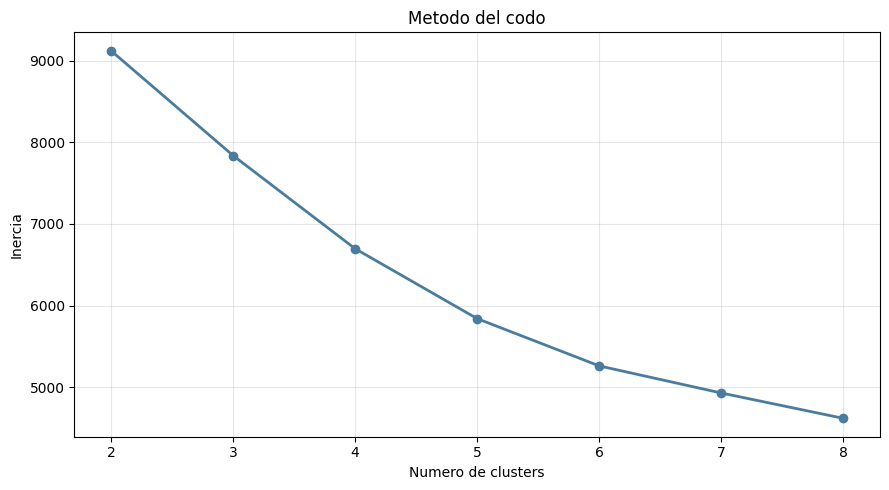

k = 2 | inercia = 9122.0
k = 3 | inercia = 7837.0
k = 4 | inercia = 6696.0
k = 5 | inercia = 5839.0
k = 6 | inercia = 5260.0
k = 7 | inercia = 4928.0
k = 8 | inercia = 4618.0


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(2, 9), inercias, marker='o', color='#4A7C9E', linewidth=2)
ax.set_xlabel('Numero de clusters')
ax.set_ylabel('Inercia')
ax.set_title('Metodo del codo')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for k, i in zip(range(2, 9), inercias):
    print("k =", k, "| inercia =", round(i, 0))

# K =5 : Perfil de cada cluster

La reduccion de inercia se aplana a partir de K=5, por tanto el modelo designa 5 clusters para llevar a cabo una acción comercial

In [16]:
K = 5

km = KMeans(n_clusters=K, random_state=42, n_init=10)
perfil['cluster'] = km.fit_predict(X_esc)

In [17]:
# Perfilar cada cluster
resumen = perfil.groupby('cluster').agg(
    n_hogares=('household_key', 'count'),
    descuento_medio=('descuento_medio', 'mean'),
    pct_promo=('pct_compras_promo', 'mean'),
    pct_blanca=('pct_marca_blanca', 'mean'),
    gasto_visita=('gasto_por_visita', 'mean'),
    n_visitas=('n_visitas', 'mean'),
    gasto_total=('gasto_total', 'mean'),
    pct_canjea=('canjea_cupones', 'mean')
).round(3)


In [18]:
resumen['pct_hogares'] = (resumen['n_hogares'] / len(perfil) * 100).round(1)
resumen.head(5)

,n_hogares,descuento_medio,pct_promo,pct_blanca,gasto_visita,n_visitas,gasto_total,pct_canjea,pct_hogares
cluster,,,,,,,,,
0,366,0.121,0.466,0.224,64.838,84.620,5309.418,0.309,14.6
1,578,0.098,0.377,0.202,27.221,81.983,2304.240,0.095,23.1
2,501,0.190,0.607,0.352,28.486,85.220,2356.846,0.198,20.0
3,163,0.131,0.502,0.306,23.313,429.153,9265.804,0.442,6.5
4,892,0.134,0.483,0.337,24.423,94.770,2344.440,0.107,35.7


Con la tabla de perfiles delante, estos son los cinco grupos que
encuentro y lo que me llama la atencion de cada uno:

Premium (366 hogares, 14,6%): gastan 64,84 $ por visita, el doble
que cualquier otro grupo, pero con descuento medio bajo y poca
marca blanca. Vienen menos veces pero llenan el carro.

Indiferentes al precio (578 hogares, 23,1%): el descuento mas bajo
de todos y solo el 37,7% de sus compras en promocion. Apenas
canjean cupones. Compran lo que necesitan cuando lo necesitan, asi
que promocionarles es basicamente regalar margen.

Cazadores de ofertas (501 hogares, 20%): el perfil opuesto.
Descuento medio del 19% (el mas alto) y el 60,7% de sus compras en
promocion. Optimizan precio de forma sistematica.

Intensivos (163 hogares, 6,5%): 429 visitas de media, cinco veces
mas que el resto, y el gasto total mas alto con diferencia. Son
pocos hogares pero concentran mucho valor.

Rutinarios (892 hogares, 35,7%): el grupo mayoritario, con todos
los valores cerca de la media. Es el comprador estandar del
supermercado.

# ¿A que perfil le estamos dando el descuento?

Para saber cuanto descuento recibe cada hogar en euros, calculo
para cada linea de transaccion la diferencia entre precio de
estanteria y precio pagado, multiplicado por las unidades. Sumado
por hogar, esto me da el descuento total que ha recibido cada uno
a lo largo de todo el periodo.
Con esto puedo calcular, por segmento, que porcentaje del VALOR
total aporta y que porcentaje del DESCUENTO total consume. Si
divido ambos porcentajes, obtengo un ratio de eficiencia: mayor
que 1 significa que el segmento aporta mas valor del que consume
en descuento; menor que 1, lo contrario.

Ponemos nombre a cada uno de los cluster

In [19]:
# Nombramos clusters
nombres = {
    0: 'Premium',
    1: 'Indiferente al precio',
    2: 'Cazador de ofertas',
    3: 'Intensivo',
    4: 'Rutinario'
}
perfil['segmento'] = perfil['cluster'].map(nombres)


In [20]:
# Cruzamos con CLV
perfil = perfil.merge(clv[['household_key', 'clv_12m', 'nivel_valor']], on='household_key', how='left')

In [21]:
clv.head()

,household_key,frequency,recency,T,monetary_value,gasto_esperado,prob_vivo,clv_12m,nivel_valor,estado,segmento
0,1,77.0,655.0,660.0,55.214286,55.187528,0.999777,2175.363265,Alto,Activo,Alto · Activo
1,2,44.0,565.0,608.0,43.900909,43.898506,0.994345,1080.843589,Medio,En riesgo,Medio · En riesgo
2,3,45.0,590.0,598.0,57.920000,57.863917,0.999611,1487.745046,Medio,Activo,Medio · Activo
3,4,29.0,523.0,607.0,37.030000,37.067140,0.973024,599.392046,Bajo,En riesgo,Bajo · En riesgo
4,5,32.0,618.0,626.0,24.205625,24.308317,0.999553,430.343048,Bajo,Activo,Bajo · Activo


In [22]:
# Cuanto descuento recibe cada segmento en euros
descuento_total = trans.groupby('household_key').apply(
    lambda g: ((g['PRICE_SHELF'] - g['PRICE_PAID']) * g['QUANTITY']).sum()
).reset_index(name='descuento_recibido')

descuento_total.head(5)

/tmp/ipykernel_547/2702596859.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  descuento_total = trans.groupby('household_key').apply(


,household_key,descuento_recibido
0,1,685.07
1,2,333.50
2,3,668.28
3,4,115.65
4,5,118.33


In [23]:
cols_limpias = ['household_key', 'gasto_total', 'n_visitas', 'descuento_medio',
                'pct_compras_promo', 'pct_marca_blanca', 'ticket_medio',
                'gasto_por_visita', 'canjea_cupones', 'cluster', 'segmento']
perfil = perfil[cols_limpias].copy()

perfil.columns.tolist()

['household_key',
 'gasto_total',
 'n_visitas',
 'descuento_medio',
 'pct_compras_promo',
 'pct_marca_blanca',
 'ticket_medio',
 'gasto_por_visita',
 'canjea_cupones',
 'cluster',
 'segmento']

In [24]:
perfil = perfil.merge(clv[['household_key', 'clv_12m', 'nivel_valor']], on='household_key', how='left')

descuento_total = trans.groupby('household_key').apply(
    lambda g: ((g['PRICE_SHELF'] - g['PRICE_PAID']) * g['QUANTITY']).sum()
).reset_index(name='descuento_recibido')

perfil = perfil.merge(descuento_total, on='household_key', how='left')

perfil.columns.tolist()

/tmp/ipykernel_547/1305583410.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  descuento_total = trans.groupby('household_key').apply(


['household_key',
 'gasto_total',
 'n_visitas',
 'descuento_medio',
 'pct_compras_promo',
 'pct_marca_blanca',
 'ticket_medio',
 'gasto_por_visita',
 'canjea_cupones',
 'cluster',
 'segmento',
 'clv_12m',
 'nivel_valor',
 'descuento_recibido']

In [25]:
analisis = perfil.groupby('segmento').agg(
    n_hogares=('household_key', 'count'),
    clv_medio=('clv_12m', 'mean'),
    clv_total=('clv_12m', 'sum'),
    descuento_medio_eur=('descuento_recibido', 'mean'),
    descuento_total_eur=('descuento_recibido', 'sum')
)


#La eficiencia promocional por segmentos (valor aportado dividido entre descuento consumido)

In [26]:
analisis['pct_valor'] = analisis['clv_total'] / analisis['clv_total'].sum() * 100
analisis['pct_descuento'] = analisis['descuento_total_eur'] / analisis['descuento_total_eur'].sum() * 100
analisis['eficiencia'] = analisis['pct_valor'] / analisis['pct_descuento']

analisis.sort_values('eficiencia', ascending=False)

,n_hogares,clv_medio,clv_total,descuento_medio_eur,descuento_total_eur,pct_valor,pct_descuento,eficiencia
segmento,,,,,,,,
Indiferente al precio,578,1164.198178,6.694140e+05,278.774827,161131.85,16.516617,11.645720,1.418256
Premium,366,2689.090122,9.842070e+05,781.197760,285918.38,24.283584,20.664600,1.175130
Intensivo,163,4670.388476,7.612733e+05,1502.630429,244928.76,18.783086,17.702097,1.061066
Rutinario,892,1176.140418,1.049117e+06,416.427814,371453.61,25.885131,26.846614,0.964186
Cazador de ofertas,501,1175.570911,5.889610e+05,639.085389,320181.78,14.531582,23.140969,0.627959


El resultado muestra
- El  cluster Cazador de ofertas es el 20% de los hogares (501), consume el 23.1% del descuento total, pero solo aporta el 14.5% del valor. Su eficiencia es 0.63: por
cada euro de descuento que recibe, devuelve solo 63 centimos de
valor relativo.

- El cluster Indiferente al precio consume el 11.6% del
descuento y aporta el 16.5% del valor - eficiencia 1.42, el mas
eficiente de todos. Es precisamente el perfil que menos necesita
el incentivo.


Este análisis es la consecuencia de dar descuentos a todos los hogares por igual: quien busca activamente ofertas las encuentra y las usa, quien no las busca simplemente no las aprovecha.


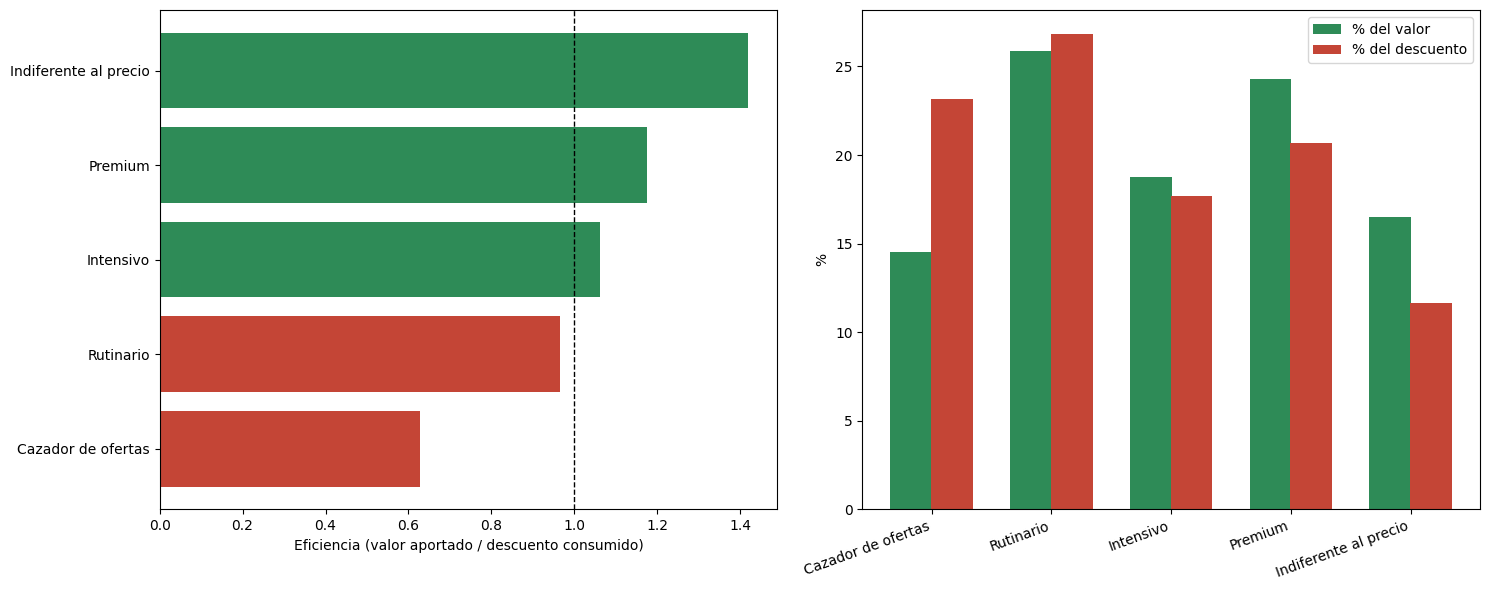

In [27]:
datos = analisis.reset_index().sort_values('eficiencia')
colores = ['#C44536' if e < 1 else '#2E8B57' for e in datos['eficiencia']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.barh(datos['segmento'], datos['eficiencia'], color=colores)
ax1.axvline(1, color='black', linestyle='--', linewidth=1)
ax1.set_xlabel('Eficiencia (valor aportado / descuento consumido)')

x = np.arange(len(datos))
ax2.bar(x - 0.17, datos['pct_valor'], 0.35, label='% del valor', color='#2E8B57')
ax2.bar(x + 0.17, datos['pct_descuento'], 0.35, label='% del descuento', color='#C44536')
ax2.set_xticks(x)
ax2.set_xticklabels(datos['segmento'], rotation=20, ha='right')
ax2.set_ylabel('%')
ax2.legend()

plt.tight_layout()
plt.show()

In [28]:
fig.savefig(RUTA_FIGURAS + 'segmentacion_promocional.png', dpi=150, bbox_inches='tight')

In [29]:
perfil.to_csv(RUTA_PROCESADOS + 'segmentacion_promocional.csv', index=False)
analisis.to_csv(RUTA_PROCESADOS + 'eficiencia_por_segmento.csv')

El hallazgo mas relevante es que el retailer aplica el descuento de
forma pareja a todos los hogares, sin diferenciar por perfil. Al
ordenar los segmentos por eficiencia (valor aportado dividido entre
descuento consumido), tres perfiles salen por encima de 1
- Indiferente al precio (1.42), Premium (1.18) e Intensivo (1.06) -
lo que significa que devuelven mas valor del descuento que reciben.

En el otro extremo esta el Cazador de ofertas, con una eficiencia de
0.63: consume el 23% del presupuesto promocional pero solo aporta
el 14.5% del valor. El Rutinario queda casi en el punto de
equilibrio (0.96).

Esto sugiere que el retailer podria mejorar la eficiencia de su
gasto promocional reduciendo la intensidad del descuento dirigido
al Cazador de ofertas, sin necesidad de tocar el resto de perfiles,
que ya estan proximos o por encima del equilibrio.
El descuento generalizado esta transfiriendo margen hacia el segmento que menos valor devuelve.

In [30]:
from google.colab import files

In [31]:
!jupyter nbconvert --to html "/content/drive/MyDrive/UCM -master Data Science/TFM/notebooks/05_Segmentacion_Promocional.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/UCM -master Data Science/TFM/notebooks/05_Segmentacion_Promocional.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 478229 bytes to /content/drive/MyDrive/UCM -master Data Science/TFM/notebooks/05_Segmentacion_Promocional.html
